# Calling copy number from single-cell DNA with HMMcopy

Before you can assign cells to clones, or align expression to dosage, something has to turn read
depth into copy number. **[HMMcopy](https://bioconductor.org/packages/HMMcopy/)** (Shah lab) is the
standard tool for that on single-cell WGS: correct depth for GC and mappability, then segment it with
a hidden Markov model.

This runs it **in this notebook's own kernel** (`R (iscc-hmmcopy)`), so its own plotting works and
the corrected object is here to look at.

| file | what it is | who sees it |
|---|---|---|
| `reads.csv` | bins × cells read counts | the tool |
| `bins.csv` | each bin's contig, position, GC and mappability | the tool |
| `cell_annotation.csv` | which cells are the diploid normal reference | the tool |
| `truth_clone.csv`, `truth_consensus.csv` | each cell's true clone and its true copy number | **scoring only** |

Generated by `python validation/make_analysis_data.py --only dna`; the truth is laid out in
[The analysis dataset and its ground truth](analysis_ground_truth.ipynb).

**What this feeds.** The per-clone profiles called here are the copy number
[clonealign](tool_clonealign_R.ipynb) is given. Handing it iscc's true copy number instead would
answer half of that benchmark's question for it.

**Two modelling choices worth stating.** The cells were sequenced with **uniform** amplification
(DLP+-style shallow WGS), not MDA/MALBAC — lumpy amplification leaves the median bin at zero reads,
which is fine for genotyping and useless for depth-based copy number. And **diploid normal cells were
sequenced alongside**, because HMMcopy calls each cell's own modal state neutral: on a
whole-genome-doubled tumour every state comes back halved unless something outside the cell fixes
the scale.

In [1]:
suppressWarnings(suppressMessages({ library(HMMcopy); library(data.table); library(ggplot2) }))
source("r_preamble.R")

data_dir <- file.path(analysis_dir("dna"), "hmmcopy")
reads <- read.csv(file.path(data_dir, "reads.csv"), row.names = 1, check.names = FALSE)
bins  <- read.csv(file.path(data_dir, "bins.csv"),  row.names = 1, check.names = FALSE)
annot <- read.csv(file.path(data_dir, "cell_annotation.csv"))

normal_cells <- annot$cell[annot$is_normal == 1]
tumour_cells <- annot$cell[annot$is_normal == 0]
cat(sprintf("%d bins over %d contigs; %d cells (%d tumour, %d diploid reference)\n",
            nrow(bins), length(unique(bins$chr)), ncol(reads),
            length(tumour_cells), length(normal_cells)))
cat(sprintf("reads per bin: median %d, range %d-%d\n",
            as.integer(median(as.matrix(reads))), min(reads), max(reads)))

240 bins over 12 contigs; 260 cells (200 tumour, 60 diploid reference)


reads per bin: median 1248, range 0-11418


## Correcting one cell — `correctReadcount`

HMMcopy's first job is to take the systematic bias out of read depth. `correctReadcount` fits the
depth–GC relationship by loess and divides it out, then does the same for mappability. Its own
diagnostic plots show both, before and after.

The `mappability = 0.6` cut is not the 0.9 default: `iscc`'s modelled mappability spans about
0.33–1.0, and at 0.9 too few bins survive the "ideal" filter for the GC loess to fit at all.

Warning message:
“k-d tree limited by memory. ncmax= 234”


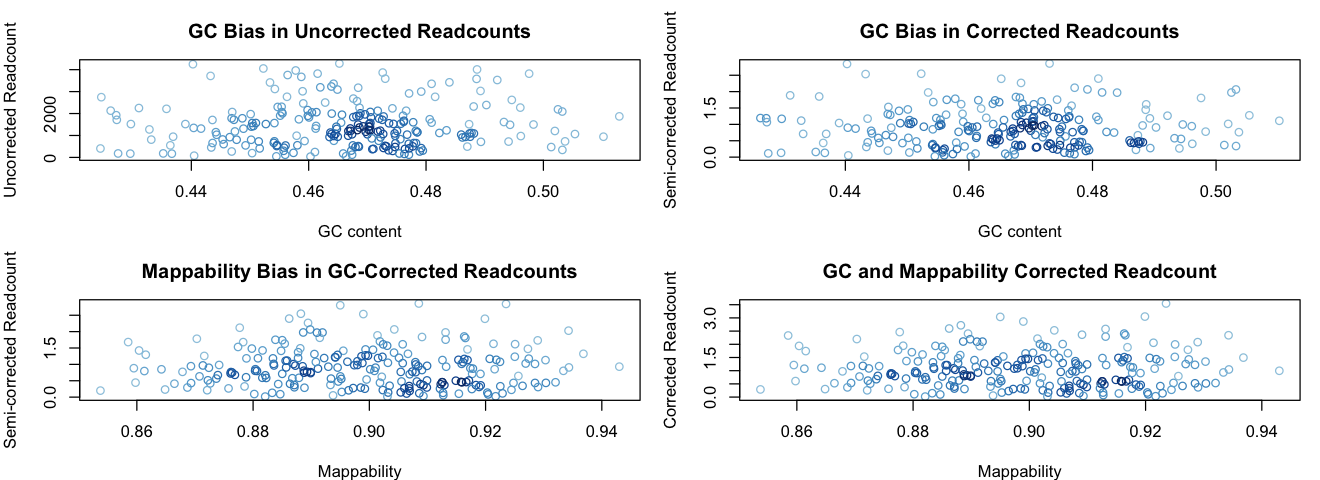

In [2]:
one <- function(cell) {
  data.table(chr = factor(bins$chr), start = as.integer(bins$start), end = as.integer(bins$end),
             reads = as.integer(reads[[cell]]), gc = as.numeric(bins$gc), map = as.numeric(bins$map))
}
corrected <- correctReadcount(one(tumour_cells[1]), mappability = 0.6, verbose = FALSE)

options(repr.plot.width = 11, repr.plot.height = 4)
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
plotBias(corrected)

## Segmenting it — `HMMsegment`

With depth corrected, the HMM assigns each bin a copy-number state. `plotSegments` is HMMcopy's own
figure: corrected depth per bin, coloured by the state the HMM assigned, with the segment medians
drawn over it.

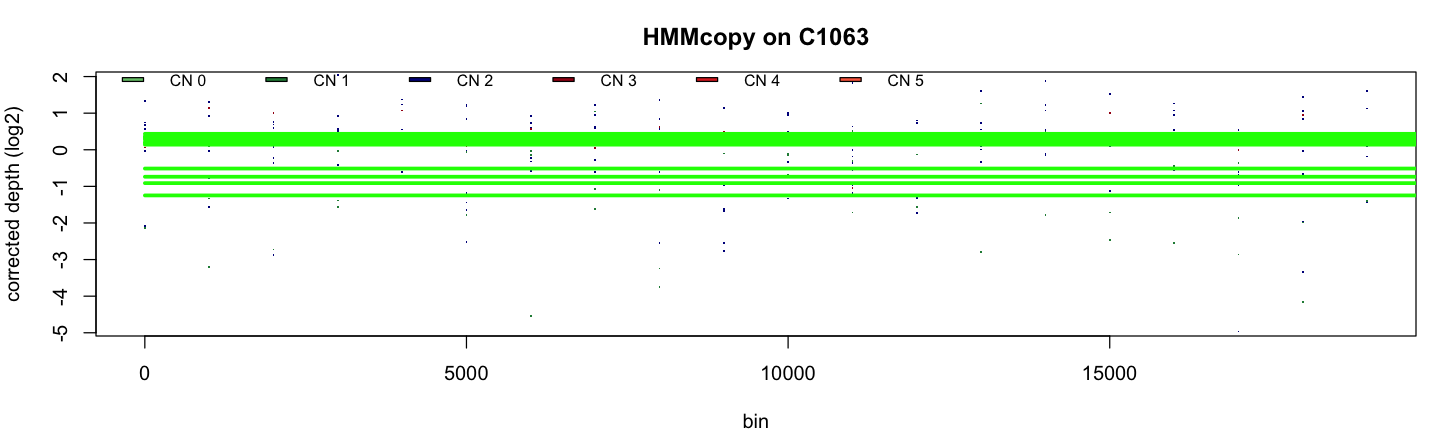

In [3]:
segments <- HMMsegment(corrected, verbose = FALSE)

options(repr.plot.width = 12, repr.plot.height = 3.6)
par(mar = c(4, 4, 3, 1))
plotSegments(corrected, segments, pch = ".",
             ylab = "corrected depth (log2)", xlab = "bin",
             main = sprintf("HMMcopy on %s", tumour_cells[1]))
legend("topleft", legend = paste("CN", 0:5), fill = stateCols(), horiz = TRUE,
       bty = "n", cex = 0.8)

## Every cell

The same two calls over the whole run. `state` is 1–6 for copy number 0–5+, so copy number is
`state − 1`.

In [4]:
call_cell <- function(cell) {
  d <- one(cell)
  r <- try(suppressWarnings({
    cor <- correctReadcount(d, mappability = 0.6, verbose = FALSE)
    s   <- HMMsegment(cor, verbose = FALSE)
    list(state = as.numeric(s$state), copy = as.numeric(cor$copy))
  }), silent = TRUE)
  if (inherits(r, "try-error")) NULL else r
}

fits  <- lapply(colnames(reads), call_cell); names(fits) <- colnames(reads)
ok    <- !vapply(fits, is.null, logical(1))
state <- sapply(fits[ok], function(f) f$state)      # bins x cells
copyl <- sapply(fits[ok], function(f) f$copy)
cat(sprintf("called %d of %d cells\n", sum(ok), ncol(reads)))
cat("state distribution (CN = state - 1):\n"); print(table(state - 1))

called 260 of 260 cells


state distribution (CN = state - 1):



    0     1     2     3     4 
 1015 10100 41420  9725   140 


## Turning relative copy number into absolute — and what that cannot fix

HMMcopy normalises depth *within* a cell, so it calls that cell's own modal state neutral. The
diploid cells sequenced in the same run are the anchor: a tumour cell's copy number is twice its
corrected depth relative to theirs.

Watch what that does and does not buy. It pins the reference cells to exactly 2, which is the check
that the anchor works at all. It does **not** recover the whole-genome doubling — and the reason is
structural rather than a tuning failure, so it is worth seeing in the output below.

In [5]:
ref  <- apply(2 ^ copyl[, colnames(copyl) %in% normal_cells, drop = FALSE], 1, median, na.rm = TRUE)
absn <- 2 * (2 ^ copyl) / ref                          # bins x cells, absolute copy number

seg_of <- bins$chr
segments_cn <- t(sapply(sort(unique(seg_of)), function(s)
  apply(absn[seg_of == s, , drop = FALSE], 2, median, na.rm = TRUE)))
rownames(segments_cn) <- sort(unique(seg_of))          # segments x cells

cat("modal called state before anchoring (CN):",
    as.integer(names(which.max(table(state - 1)))), "\n")
cat("median absolute CN after anchoring, tumour cells:",
    round(median(segments_cn[, colnames(segments_cn) %in% tumour_cells], na.rm = TRUE), 2), "\n")
cat("... diploid reference cells:",
    round(median(segments_cn[, colnames(segments_cn) %in% normal_cells], na.rm = TRUE), 2), "\n")

modal called state before anchoring (CN): 2 


median absolute CN after anchoring, tumour cells: 2.16 


... diploid reference cells: 2 


**Read the last two numbers together.** The reference cells come out at exactly 2. The tumour cells
come out at about 2, when `iscc` gave most of them 4.

That is not HMMcopy failing. A cell gets a fixed read budget, so a tetraploid cell spreads the same
reads over twice as much genome and its *per-copy* depth halves — leaving its total depth
indistinguishable from a diploid's. **Ploidy is not identifiable from depth alone**, which is why
tools that do recover it (ichorCNA, and HMMcopy pipelines built on it) run a purity-and-ploidy search
against **allele fractions** rather than depth. `iscc` emits those too, in `cell_rna_baf` and the
allele layer — see [Calling copy number from scRNA with Numbat](tool_numbat_R.ipynb), which reads
exactly that signal.

What survives is the part that matters downstream: the *relative* profile of each clone.

In [6]:
truth_clone <- read.csv(file.path(data_dir, "truth_clone.csv"))
truth_cons  <- read.csv(file.path(data_dir, "truth_consensus.csv"), row.names = 1)

lab <- truth_clone$true_clone[match(colnames(segments_cn), truth_clone$cell)]
tum <- lab >= 0
called_clone <- t(sapply(sort(unique(lab[tum])), function(k)
  round(apply(segments_cn[, tum & lab == k, drop = FALSE], 1, median, na.rm = TRUE))))
rownames(called_clone) <- rownames(truth_cons)[sort(unique(lab[tum])) + 1]

cat("per-clone called copy number\n"); print(called_clone)
cat("\ntrue copy number\n"); print(as.matrix(truth_cons))
cat(sprintf("\nwithin 1 copy of the truth: %.0f%% of (clone, segment) entries\n",
            100 * mean(abs(called_clone - as.matrix(truth_cons)) <= 1)))

l1 <- function(M) as.matrix(dist(M, method = "manhattan"))
cat("\npairwise L1 between clone profiles (called | true):\n")
print(cbind(called = l1(called_clone)[lower.tri(l1(called_clone))],
            true   = l1(as.matrix(truth_cons))[lower.tri(l1(as.matrix(truth_cons)))]))

per-clone called copy number


       chr0 chr1 chr10 chr11 chr2 chr3 chr4 chr5 chr6 chr7 chr8 chr9
clone0    2    3     3     2    1    3    1    3    2    2    1    1
clone1    2    3     3     2    1    3    1    2    3    3    1    1
clone2    2    3     1     3    1    3    1    3    2    3    1    1
clone3    2    2     1     2    1    2    1    4    3    2    2    1



true copy number


       seg0 seg1 seg2 seg3 seg4 seg5 seg6 seg7 seg8 seg9 seg10 seg11
clone0    4    4    2    4    2    4    3    4    2    2     4     4
clone1    4    4    2    4    2    4    4    4    2    2     4     4
clone2    4    4    2    5    2    4    3    5    2    2     2     4
clone3    2    2    1    2    1    3    2    2    2    1     1     2



within 1 copy of the truth: 65% of (clone, segment) entries



pairwise L1 between clone profiles (called | true):


     called true
[1,]      3    1
[2,]      4    4
[3,]      7   18
[4,]      5    5
[5,]      8   19
[6,]      7   18


## What to take from it

HMMcopy runs on `iscc`'s single-cell read depth as it would on a real DLP+ run, and its GC and
mappability corrections, its segmentation and its own figures all work. Scored against the answer
key, the called profiles land within one copy of the truth on about two thirds of segments and keep
the clones apart — while the genome doubling stays invisible, for a reason that is a property of
depth data rather than of the tool.

Those per-clone profiles are the copy number [clonealign](tool_clonealign_R.ipynb) is given. They
are worse than `iscc`'s truth, which is the point: a real study never has the truth, and a benchmark
handed it is not measuring anything.